In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# generating parameters and creating initial state
T1 = 1
T2 = .5

N = 5
dim = 2
trotter_dt = .001

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N)

In [3]:
# creating gates
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

z_gate = qt.Qobj([[1, 0],[0, -1]])

hadamard = 1 / np.sqrt(2) * qt.Qobj([[1, 1],[1, -1]])
hada_layer = tensor(tensor([hadamard] * 3), tensor([qt.qeye(dim)] * 2))

cnot_list = [cnot3, cnot4, cnot5, cnot6]


C:\Users\girgi\AppData\Local\Temp\ipykernel_4324\2783961293.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_4324\2783961293.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_4324\2783961293.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
fr

In [4]:
# create fidelity function
# add others if you want another metric 
def hilbert_schmidt_fid_func(rho, sigma):
    return np.abs((sigma * rho).tr()) / np.sqrt((rho * rho).tr() * (sigma * sigma).tr())

In [5]:
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 1)).unit(), tensor([basis(dim, 0)] * (N-1)))
rho0 = psi0 * psi0.dag()
rho_encoded = hada_layer * cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag() * hada_layer.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]]

# Quick study on absorbing the hadamard onto a cnot 

In [6]:
# -

# this raises an interesting question 
# maybe one should try to build this specific gate and run that but can this be done through hamiltonian engineering?
# can a hamiltonian be used to build any gate? in theory yes if it has enough control variables 
# is it worth simulating tho?
# The time spent on the cnot has the most impact which means that the time spent decaying in the computational basis is much worse than the time spent decaying in the encoded basis 

In [7]:
# qt.ptrace(hada_layer * states[-1] * hada_layer.dag(), [0,1,2])

In [8]:
# qt.ptrace(hada_layer * new_states[-1] * hada_layer.dag(), [0,1,2])

In [9]:
# # plot the states
# time = np.linspace(0 ,.15, len(states))
# fig, ax = plt.subplots()
# for i in range(dim ** 3):
#     # data = []
#     data2 = []
#     for j in range(len(states)):
#         # data.append(qt.ptrace(states[j], [0,1,2])[i,i])
#         data2.append(qt.ptrace(new_states[j], [0,1,2])[i,i])
#     # ax.plot(time, data)
#     print(data2[-1])
#     ax.plot(time, data2)

# end 

In [10]:
gates = [hada_layer, cnot3, cnot4, cnot5, cnot6, hada_layer]
gate_times = [.025, .1, .1, .1, .1, .025]
states = []
fids = []
plotting_states = []

for i in range(len(gates)):
    rho_evolution = trotter.apply(rho=rho_encoded, duration=gate_times[i], unitary=gates[i])
    rho_encoded = rho_evolution[-1]
    states.extend(rho_evolution)
    # if i != len(gates) - 1:
    plotting_states.extend(rho_evolution)
    # else:
    # plotting_states.extend(hada_layer * rho_evolution * hada_layer.dag())



see if you can get the same result by running the hadamards in the cnot because it may make the plotting better since doing it this way makes plotting in the computational basis weird <br />
expect the exact same final state and it better be otherwise something is wrong 

In [11]:
# recovery operation
# measurement and recovery process 
# projective measurement 
proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), z_gate, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(z_gate, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), z_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
duration_recovery = .02
recovery_states = []
for i in range(len(recovery_ops)):
    recovery = trotter.apply(density_outcomes[i], duration=duration_recovery, unitary=recovery_ops[i])
    recovery_states.append(recovery)

for i in range(int(len(recovery))):
    current_state = [outcomes[j] * recovery_states[j][i] for j in range(len(outcomes))]
    states.append(sum(current_state)/(sum(current_state)).tr())
    plotting_states.append(hada_layer * states[-1] * hada_layer.dag())
    fids.append(hilbert_schmidt_fid_func(qt.ptrace(states[-1], [0,1,2]), rho_encoded_traced))

total_time = sum(gate_times) + duration_recovery

[0.8357566525016148, 0.1009598291702533, 0.031951954415166794, 0.031331563912963434]


[0.00960115508934072, 0.004369821329631471, 0.0035513148256682476, 0.0798732515379936, 0.021948491595601305, 0.02977479018868428, 0.030658008751777245, 0.8202231666813028]


Text(0.5, 0, 'time (dt)')

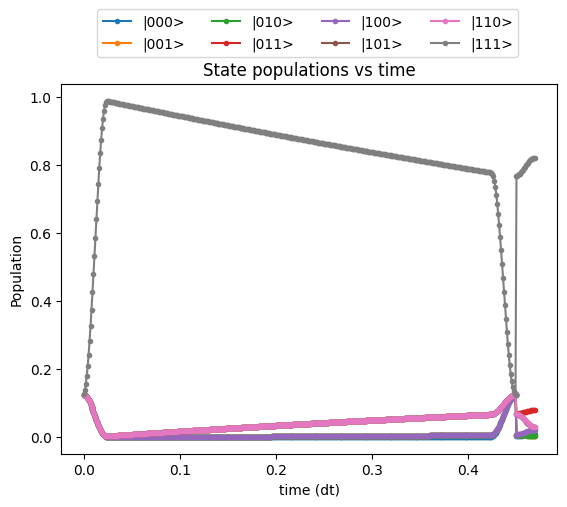

In [12]:
time = np.linspace(0, total_time, len(states))
time = np.linspace(0, total_time, len(plotting_states))
# plot population
populations = []
state_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
fig, ax = plt.subplots()
for i in range(dim ** (N-2)):
    data = []
    # for j in range(len(states)):
    for j in range(len(plotting_states)):
        data.append(np.real(qt.ptrace(plotting_states[j], [0,1,2])[i,i]))
    ax.plot(time, data, marker = ".", label = state_labels[i])
    populations.append(data[-1])
print(populations)
fig.legend(bbox_to_anchor=(.85, 1.05), ncol=dim ** (N-2)/2)
ax.set_title("State populations vs time")
ax.set_ylabel("Population")
ax.set_xlabel("time (dt)")